# **2.** Datasets

In the first notebook, we have learnt the basics of data representations, and how data such as text, music and images is stored as numbers in a computer. Later, we also explored how to extract useful information from these representations.

But, what is the natural next step for teaching a machine how to make decisions? 

Well, we need to have data to work with! Think of it as examples the computer can look at to learn. We refer to this collection of data as a **dataset**.

Ideally, a **dataset** should meet the following criteria:

- Contain a **large number** of examples, and we will call each of them a **sample**, **observation** or **instance**;
- Be **representative** of the whole scope of possibilities we could encounter in the task we want to accomplish;
- Be available under a **permissive license** that allows for training machine learning models with non-commercial applications.

There are many available datasets that we can use for different applications, but we will select a relevant one for each type of data (text, music and images) to explore how to work with them.

 > Want to know what else is out there? You could look for available datasets on popular websites such as [`kaggle`](https://www.kaggle.com/datasets)!


## 1. Text: IMDB Dataset of 50K Movie Reviews

To continue our adventure analysing text, we'll take a look at the [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/data).

This dataset includes processed data from the [Large Movie Review Dataset](https://ai.stanford.edu/~amaas/data/sentiment/), which was released under a ??? License. This means we can use it to train a model.


For each sample of data representing a movie, this database presents the following information:

* _review_: Text of the review
* _sentiment_: Whether the review was positive or negative


This is what we call a `labeled dataset`, because for each sample we have a `label`, in this case the `sentiment` value.

Imagine we want to teach the computer how to distiguish a good review from a bad review: We will need to show it several examples of reviews and tell it what conclusion it should arrive to in each case. Is it a good or a bad review? That desired output we show for each is example is the `label`.

### 1.i Download the dataset, load and clean data

For working with the dataset in this notebook, we can simply download it using the `kaggle` package.

In [7]:
!pip install kaggle
# Download the Netflix Movies and TV Shows dataset from Kaggle
!kaggle datasets download lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
imdb-dataset-of-50k-movie-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


Since the dataset is in a zip file, we need to extract its content.

In [8]:
import zipfile
with zipfile.ZipFile("imdb-dataset-of-50k-movie-reviews.zip", 'r') as zip_ref:
    zip_ref.extractall("imdb_dataset")

The dataset is in the form of a `csv` file, that is _comma separated values_ that indicate data in the form of a table (like an Excel spreadsheet).
A useful library for working with `csv` files is `pandas`, which is usually referred to in code as `pd`.

Let's read the dataset from the `csv` file.

In [9]:
import pandas as pd

imdb_dataset = pd.read_csv("imdb_dataset/IMDB Dataset.csv", encoding='utf-8')

Let's clean up the review texts.

In [10]:
# Remove <br /> tags from reviews
imdb_dataset['review'] = imdb_dataset['review'].str.replace('<br />', '', regex=False)

# Remove non-printable characters from reviews
imdb_dataset['review'] = imdb_dataset['review'].str.replace('[\x00-\x1f]', '', regex=True)

# Remove selected punctuation/symbols from reviews
chars_to_remove = [",", ".", "?", "!", '"', ";", ")", "(", "\t", "*", "-", "_", ":",
                   "/", "\\", "|", "@", "#", "$", "%", "^", "&", "~", "`", "[", "]",
                   "{", "}", "<", ">", "+", "="]
for ch in chars_to_remove:
    imdb_dataset['review'] = imdb_dataset['review'].str.replace(ch, " ", regex=False)

# Replace multiple spaces with a single space
imdb_dataset["review"] = imdb_dataset["review"].str.replace("  ", " ", regex=False)

### 1.ii Exploring the Dataset



Let's visualise the data that's available. How many movie reviews do we have? What are the columns in the dataset? What does the data look like for the first few rows?

In [11]:
# Check the structure and columns
print("Number of titles:", imdb_dataset.shape[0])

print("\nColumn names:")
print(imdb_dataset.columns.tolist())

print("\nFirst few rows:")
imdb_dataset.head()

Number of titles: 50000

Column names:
['review', 'sentiment']

First few rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production The filming tech...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,Petter Mattei's Love in the Time of Money is a...,positive


We have 50000 reviews that are labeled as positive or negative. But how many do we have for each case exactly?

Distribution of content types:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


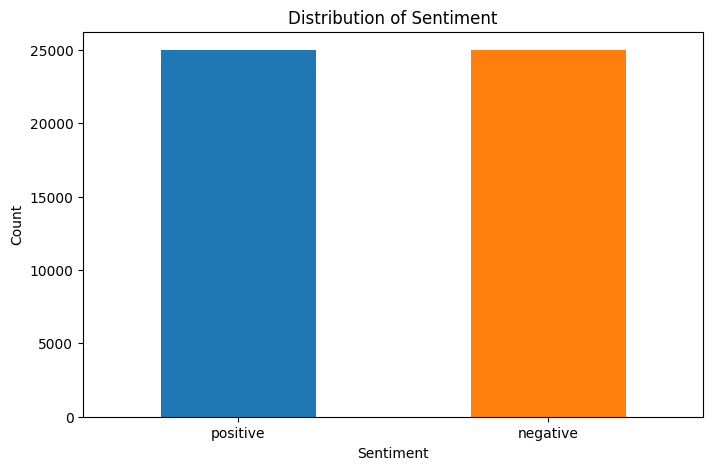

In [12]:
import matplotlib.pyplot as plt

# Check the distribution of positive and negative reviews
print("Distribution of content types:")
print(imdb_dataset['sentiment'].value_counts())


# Visualize the distribution
plt.figure(figsize=(8, 5))
imdb_dataset['sentiment'].value_counts().plot(kind='bar', color=['#1f77b4', '#ff7f0e'])
plt.title('Distribution of Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

We have 25000 samples for each class, which means we are dealing with a _balanced_ dataset.

Next, we'll aim at analysing how the text of positive reviews differ from the ones from negative reviews.


### 1-iii. Most common words in reviews

Let's analyze the most common words in reviews.

We have previously learnt how to perform this analysis for a single text. When we had just one text to analyse, our procedure was to simply use a counter to discover the frequency of each word or bigram. 

Now the situation is a bit different, since we have many different texts and two classes. How can we consider the information of many different texts to get an idea of how positive and negative reviews tend to behave?

While we will join all descriptions for movies and follow the procedure of the previous notebook to build the vocabulary, it would be helpful for our future tasks to preserve some sense of structure in the information: we need to be able to trace back how many times each word appeared in each individual review.

To build our vocabulary, we need to consider all the text we have in all the reviews. We will also remove common words from English that don't give us much information (eg. 'a', 'the'), we do that ignoring everything in the `ENGLISH_STOP_WORDS` varible.

In [13]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def build_vocabulary(text):
    # turn all letters to lower case
    text_lower = text.lower()
    # replace newline characters with spaces
    text_spaces = text_lower.replace("\n", " ")
    # split the text into a list of words
    word_list = text_spaces.split(" ")
    # remove everything that is not a word (e.g., numbers, punctuation)
    word_list = [w for w in word_list if any(ch.isalpha() for ch in w)]
    # remove stop words
    word_list = [w for w in word_list if w not in ENGLISH_STOP_WORDS]
    
    # get the unique words
    unique_words = sorted(set(word_list))
    
    # build the vocabulary
    vocabulary = {}
    for i, word in enumerate(unique_words):
        vocabulary[word] = i
    
    return vocabulary, word_list

Let's join all the reviews and create the vocabulary.

In [14]:
# join all the texts
all_reviews = " ".join(imdb_dataset['review'])
# build vocabulary and get the list of words
vocabulary, words_list = build_vocabulary(all_reviews)

From the words in our vocabulary, what are the 50 most common ones?

In [15]:
from collections import Counter

# count the frequency of each word in the list
word_counts = Counter(words_list)
# get the 50 most common words and their counts
word_counts.most_common(50)

[('movie', 87014),
 ('film', 77645),
 ('like', 40140),
 ('just', 35140),
 ("it's", 33462),
 ('good', 29638),
 ('time', 25021),
 ('really', 23081),
 ('story', 22947),
 ('bad', 18381),
 ('great', 18113),
 ('people', 17822),
 ("don't", 16843),
 ('make', 15871),
 ('way', 15630),
 ('movies', 15248),
 ('think', 14333),
 ('characters', 14231),
 ('watch', 13935),
 ('films', 13706),
 ('seen', 13363),
 ('character', 13310),
 ('plot', 12909),
 ('love', 12892),
 ('acting', 12825),
 ('life', 12729),
 ('did', 12586),
 ('best', 12584),
 ('know', 12479),
 ('little', 12400),
 ('does', 11600),
 ('better', 11420),
 ('end', 11092),
 ('man', 11030),
 ('scene', 10891),
 ('say', 10753),
 ('scenes', 10458),
 ('real', 9354),
 ("i'm", 9340),
 ('watching', 9154),
 ('thing', 9116),
 ("doesn't", 8837),
 ('actors', 8807),
 ('funny', 8736),
 ('years', 8734),
 ("didn't", 8721),
 ('old', 8591),
 ('work', 8533),
 ('actually', 8461),
 ('makes', 8303)]

We can visualise this in a histogram. Let's only plot the 20 most common words so it's easier to see.

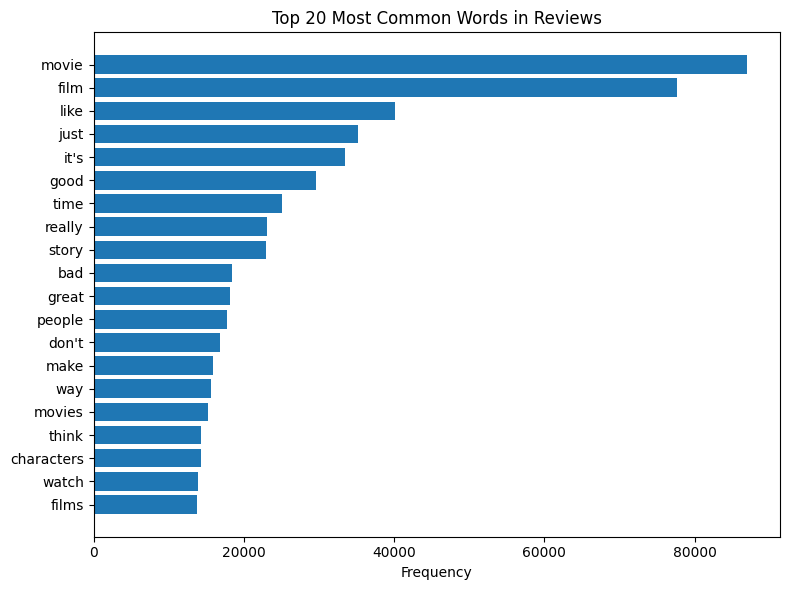

In [16]:
import matplotlib.pyplot as plt

top_n = 20
top_common = word_counts.most_common(top_n)
top_common_words = [word for word, count in top_common]
top_common_frequencies = [count for word, count in top_common]

plt.figure(figsize=(8, 6))
plt.barh(top_common_words, top_common_frequencies, color='#1f77b4')
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words in Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

As we explained before, we need to keep track of the **counts for each one of the top words, for every review**.

If we want to consider the 50 most common words, we should build a matrix of shape 50000 (number of reviews) x 50 (number of top words to consider), to store this information. Then, for each review, we need to count how many times each of the common words appears.

In [17]:
import numpy as np

# get the 50 most common words
top_n = 50
top_common = word_counts.most_common(top_n)
top_common_words = [word for word, count in top_common]

# create a matrix to store the word counts for each review
num_reviews = imdb_dataset.shape[0]
word_counts_per_review = np.zeros((num_reviews, top_n))

for i, review in enumerate(imdb_dataset['review']):
    # for each review, split it into words
    review_words = review.split(" ")
    for j, word in enumerate(top_common_words):
        # for each top common word, count how many times it appears in the review and store it in the matrix
        word_counts_per_review[i, j] = review_words.count(word)

Let's store the matrix information on a `pandas` `dataframe` to analyse it easily. Let's rename `sentiment` as `label`.

In [18]:
# create a DataFrame from the word counts matrix and add the sentiment labels
word_counts_per_review_df = pd.DataFrame(word_counts_per_review, columns=top_common_words)
# add the sentiment labels to the DataFrame
word_counts_per_review_df["label"] = imdb_dataset["sentiment"]

How does this data look?

In [19]:
word_counts_per_review_df.head()

,movie,film,like,just,it's,good,time,really,story,bad,...,doesn't,actors,funny,years,didn't,old,work,actually,makes,label
0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,positive
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,positive
3,3.0,2.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,negative
4,1.0,2.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,positive


Remember that:
- Each **row** represents one movie review
- Each **column** represents a word from the vocabulary of 50 most common words
- Each **number** shows how many times that word appears in that review
- Most cells are **0** because most words don't appear in most reviews!

Given this table, we can count how many times each top word appeared along all descriptions. For this, we need to sum all the information in each column (counts for a given word) for all rows (different descriptions). We can do that with the `sum` method, choosing `axis=0` to indicate we are summing along columns. If we do this, we should get the same histogram as before!

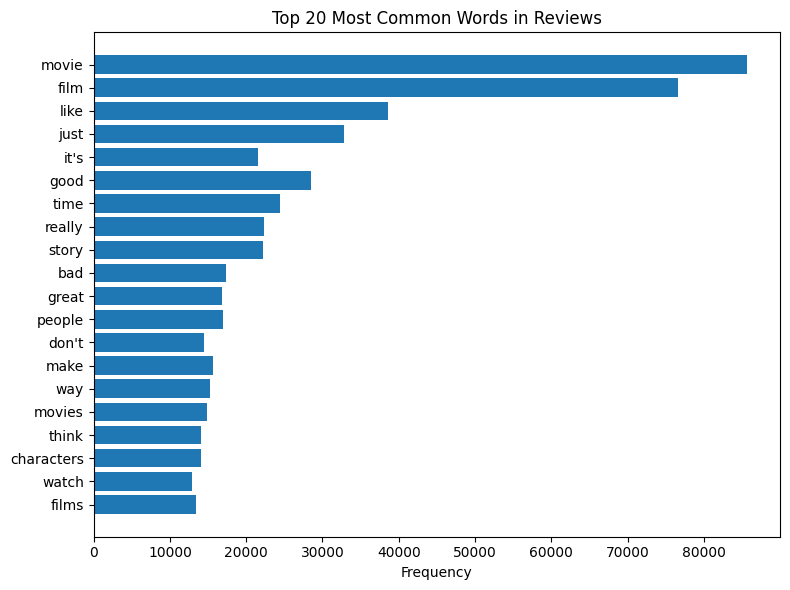

In [20]:
# rearrange top words in order of frequency and get only top 20
word_freqs =  word_counts_per_review_df.drop(columns='label').sum(axis=0)
top_n_vis = 20

# Visualize single histogram
plt.figure(figsize=(8, 6))
plt.barh(top_common_words[:top_n_vis], word_freqs[:top_n_vis], color='#1f77b4')
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words in Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


But, what about the behaviour for positive and negative reviews? We can filter the reviews for each label and do separate histograms to understand how the two cases differ.

In [21]:
# this is a vector thats True for positive reviews and False for negative reviews
positive_mask = imdb_dataset['sentiment'] == 'positive'
# this is a vector thats True for negative reviews and False for positive reviews
negative_mask = imdb_dataset['sentiment'] == 'negative'

# keep only the rows of the word counts matrix that correspond to positive and negative reviews, respectively
positive_word_counts_df = word_counts_per_review_df[positive_mask.values]
negative_word_counts_df = word_counts_per_review_df[negative_mask.values]

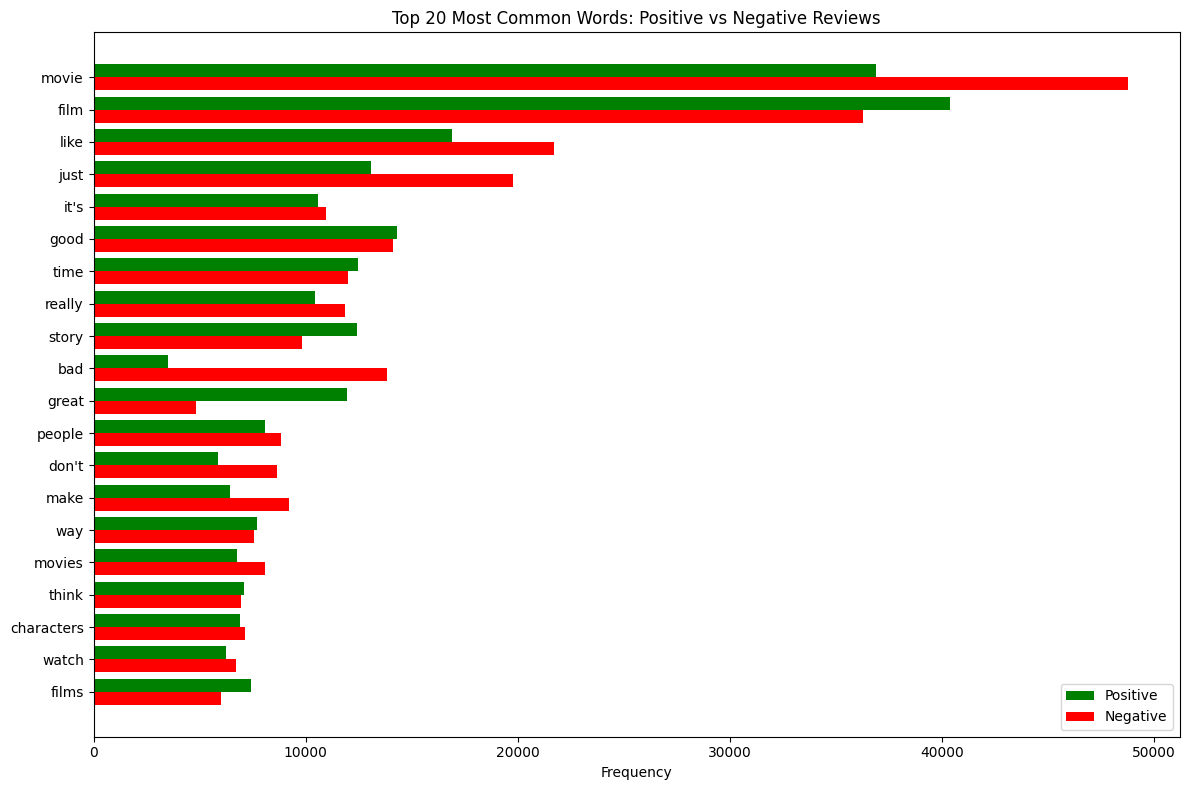

In [22]:
word_freqs_positive = positive_word_counts_df.drop(columns='label').sum(axis=0).values
word_freqs_negative = negative_word_counts_df.drop(columns='label').sum(axis=0).values

# Visualize both on the same graph (grouped horizontal bars)
top_n_vis = 20
words_to_plot = top_common_words[:top_n_vis]
pos_to_plot = word_freqs_positive[:top_n_vis]
neg_to_plot = word_freqs_negative[:top_n_vis]

y = np.arange(top_n_vis)
bar_height = 0.4

plt.figure(figsize=(12, 8))
plt.barh(y - bar_height/2, pos_to_plot, height=bar_height, color='green', label='Positive')
plt.barh(y + bar_height/2, neg_to_plot, height=bar_height, color='red', label='Negative')

plt.yticks(y, words_to_plot)
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words: Positive vs Negative Reviews')
plt.gca().invert_yaxis()  # most frequent word on top
plt.legend()
plt.tight_layout()
plt.show()

We can see that the some top words repeat in both cases, such as _movie_ or _film_. Another words are distinctive, such as _bad_ as a more common word for negative descriptions. Why do you think _good_ could be present in both negative and positive almost equally? 

### 1-iv. Most Common Bigrams (Word Pairs)

For bigrams we can take a very similar procedure.

First, we need to find all bigrams.

In [23]:
bigrams = list(zip(words_list, words_list[1:]))

How many bigrams do we have?

In [24]:
len(bigrams)

5415070

Let's check what the 50 most common bigrams are:

In [25]:
bigram_counts = Counter(bigrams)

top_bigrams_counts = bigram_counts.most_common(top_n)
top_bigrams_counts

[(("i've", 'seen'), 3441),
 (('special', 'effects'), 2235),
 (("don't", 'know'), 2182),
 (('low', 'budget'), 1819),
 (('looks', 'like'), 1675),
 (('year', 'old'), 1569),
 (('good', 'movie'), 1507),
 (('waste', 'time'), 1504),
 (("it's", 'just'), 1486),
 (('movie', 'just'), 1476),
 (("i'm", 'sure'), 1428),
 (('watch', 'movie'), 1393),
 (('sci', 'fi'), 1379),
 (('look', 'like'), 1309),
 (("don't", 'think'), 1299),
 (('new', 'york'), 1275),
 (('years', 'ago'), 1255),
 (('real', 'life'), 1224),
 (('high', 'school'), 1153),
 (('pretty', 'good'), 1119),
 (('movie', "it's"), 1108),
 (('bad', 'movie'), 1072),
 (('main', 'character'), 1066),
 (('watching', 'movie'), 1054),
 (('movie', 'like'), 1045),
 (('movie', 'really'), 995),
 (('horror', 'movie'), 978),
 (('saw', 'movie'), 958),
 (('great', 'movie'), 951),
 (('long', 'time'), 929),
 (('film', "it's"), 917),
 (('film', 'just'), 904),
 (('like', 'movie'), 899),
 (('horror', 'film'), 896),
 (('really', 'good'), 885),
 (('just', 'like'), 868),


Let's take a look at that in a histogram.

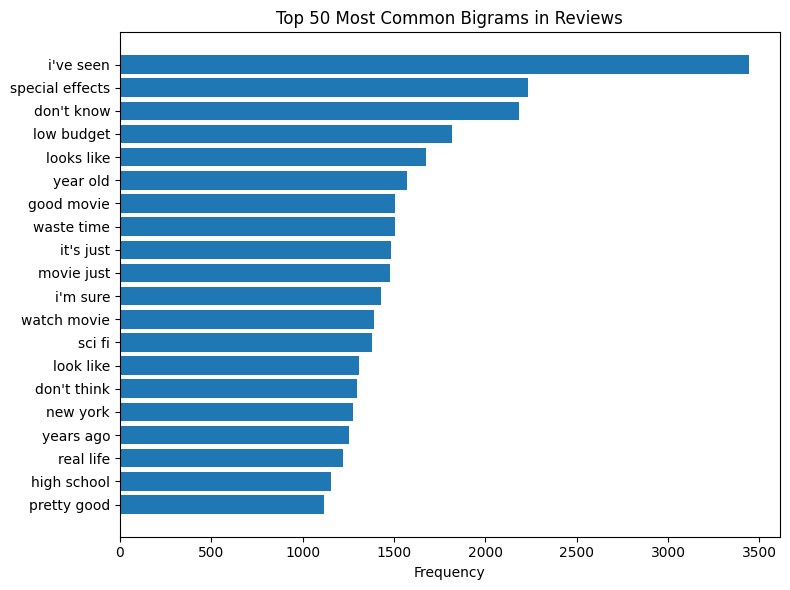

In [26]:
top_common_bigrams = [' '.join(bigram) for bigram, count in top_bigrams_counts]
top_common_frequencies = [count for bigram, count in top_bigrams_counts]

plt.figure(figsize=(8, 6))
plt.barh(top_common_bigrams[:top_n_vis], top_common_frequencies[:top_n_vis], color='#1f77b4')
plt.xlabel('Frequency')
plt.title('Top 50 Most Common Bigrams in Reviews')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [27]:
# create a matrix to store the bigram counts for each review
num_reviews = len(imdb_dataset)
num_bigrams = len(top_common_bigrams)
bigrams_counts_per_review = np.zeros((num_reviews, num_bigrams))

for i, review in enumerate(imdb_dataset['review']):
    words = review.split()
    words = [w.lower() for w in words if any(ch.isalpha() for ch in w) and w not in ENGLISH_STOP_WORDS]
    review_bigrams = [" ".join(pair) for pair in zip(words, words[1:])]
    bigrams_counts = Counter(review_bigrams)

    for j, bigram in enumerate(top_common_bigrams):
        # for each top common bigram, count how many times it appears in the review and store it in the matrix
        bigrams_counts_per_review[i, j] = bigrams_counts[bigram]

In [28]:
# create a DataFrame from the bigram counts matrix
bigrams_counts_per_review_df = pd.DataFrame(bigrams_counts_per_review, columns=top_common_bigrams)
# add the sentiment labels to the DataFrame
bigrams_counts_per_review_df["label"] = imdb_dataset["sentiment"]

In [29]:
bigrams_counts_per_review_df.head()

,i've seen,special effects,don't know,low budget,looks like,year old,good movie,waste time,it's just,movie just,...,movie movie,make movie,it's good,really bad,love story,main characters,movie good,worst movie,bad acting,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,negative
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,positive


In [30]:
positive_bigram_counts_df = bigrams_counts_per_review_df[positive_mask.values]
negative_bigram_counts_df = bigrams_counts_per_review_df[negative_mask.values]

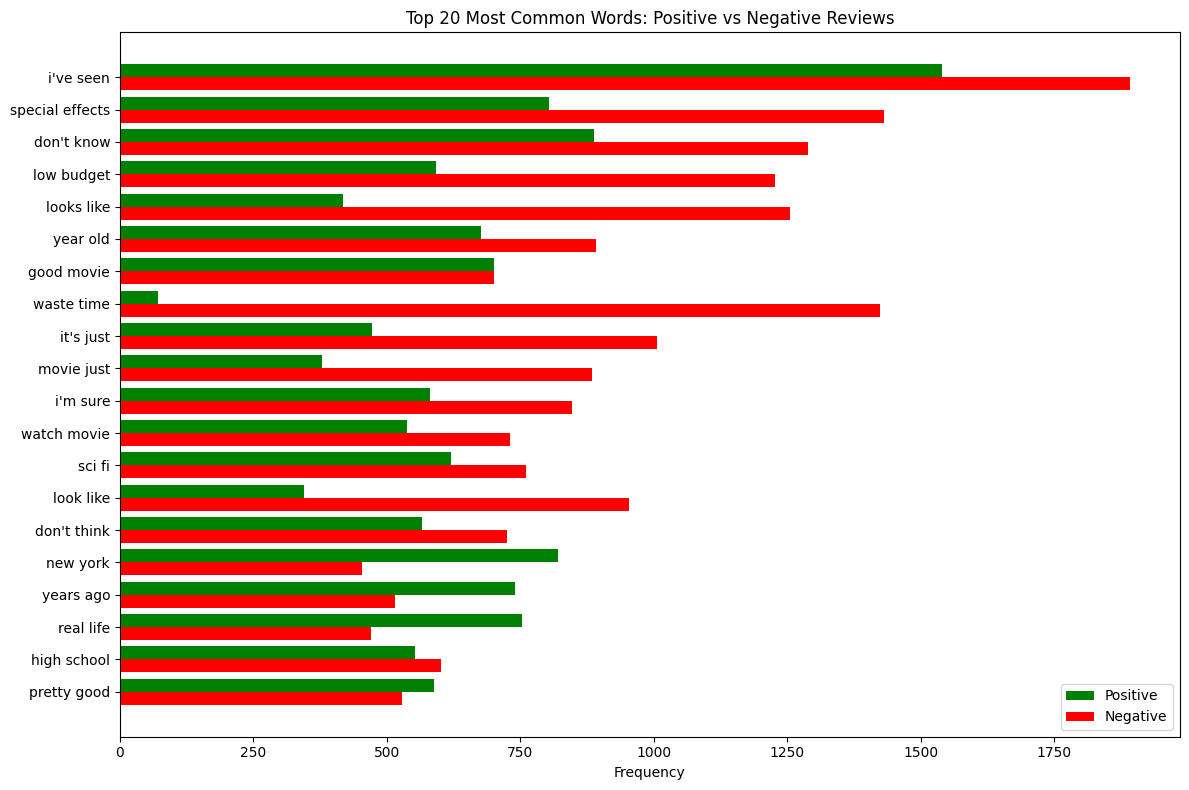

In [31]:
freqs_positive = positive_bigram_counts_df.drop(columns='label').sum(axis=0).values
freqs_negative = negative_bigram_counts_df.drop(columns='label').sum(axis=0).values

# Visualize both on the same graph (grouped horizontal bars)
top_n = 20
bigrams_to_plot = top_common_bigrams[:top_n]
pos_to_plot = freqs_positive[:top_n]
neg_to_plot = freqs_negative[:top_n]

y = np.arange(top_n)
bar_height = 0.4

plt.figure(figsize=(12, 8))
plt.barh(y - bar_height/2, pos_to_plot, height=bar_height, color='green', label='Positive')
plt.barh(y + bar_height/2, neg_to_plot, height=bar_height, color='red', label='Negative')

plt.yticks(y, bigrams_to_plot)
plt.xlabel('Frequency')
plt.title('Top 20 Most Common Words: Positive vs Negative Reviews')
plt.gca().invert_yaxis()  # most frequent word on top
plt.legend()
plt.tight_layout()
plt.show()

### 1.v - Words and bigrams features

In the end, we should have the counts for every top common word and top common biram, for every review. That table is the one we will use in the next notebook to train a model.

In [32]:
features = pd.concat(
	[
		word_counts_per_review_df.drop(columns="label"),
		bigrams_counts_per_review_df.drop(columns="label"),
	],
	axis=1,
)
features.head()


,movie,film,like,just,it's,good,time,really,story,bad,...,film making,movie movie,make movie,it's good,really bad,love story,main characters,movie good,worst movie,bad acting
0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,2.0,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,2.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### _1.vi - CountVectorizer (Bonus)_

Instead of manually creating the vocabulary and counting the words for each review we can use `CountVectorizer` feature extractor from the `sklearn` library. This is a very useful object that:
1. Creates the vocabulary of all the words in all the descriptions (in the `fit` method)
2. Counts the times each word appears in each description (in the `transform` method)
3. Stores the counts of different words for each row (each movie review) in a table

Note that this approach allows us to track where each count of words came from!

Another advantage of using `CountVectorizer` is that it can automatically filter out common stop words (for example "the", "and" or "is") that don't add information about what the text is about. That is done adding the option `stop_words='english'` to the call. We can also focus on the 50 most common words by adding the `max_features=50` option.

You can try to use the code below instead of our manual process!

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

# Create a CountVectorizer for single words
word_vectorizer = CountVectorizer(
    # remove common English stop words e.g., "the", "and", "is", they don't add much information
    stop_words='english',
    # only keep the most common 50 words
    max_features=50
)

# get word counts
word_counts = word_vectorizer.fit_transform(imdb_dataset['review'])

We can do the same for bigrams:

In [34]:
# Create a CountVectorizer for bigrams (word pairs)
bigram_vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 2),  # Bigrams only (pairs of consecutive words)
    max_features=50
)

# Get bigram counts
bigram_counts = bigram_vectorizer.fit_transform(imdb_dataset['review'])

We can then combine both:

In [35]:
from scipy.sparse import hstack

# Reuse the already computed word and bigram counts
combined_counts = hstack([word_counts, bigram_counts])

### _1.vi - TF-IDF_ (Bonus)

Instead of just counting the times a word appears in each review, we could use other metrics. One simple but useful one is TF-IDF (Term Frequency-Inverse Document Frequency), which helps us understand how important a word is in the context of our problem.

It is composed of two terms:
* Term Frequency (TF): Indicates how frequently a term (a word) appears in a document (a review), and is calculated as
 $$  \# times term appears in a document / \# terms in document $$

* Inverse Document Frequency (IDF): Measures how rare a term (a word) is across the entire text collection (all reviews). This will be low for very common words ("the", "a") and high for rare words. It's calculated as:

$$ log(\# of documents / \# of documents containing term) $$





Similarly, we can use `TfidVectorizer` for this:

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Create TF-IDF vectorizer for words
tfidf_word_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 1),  # Only single words (unigrams)
    max_features=50      # Keep top 50 words
)
# Fit and transform the reviews separately
tfidf_words = tfidf_word_vectorizer.fit_transform(imdb_dataset['review'])

# Create TF-IDF vectorizer for bigrams
tfidf_bigram_vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(2, 2),  # Only word pairs (bigrams)
    max_features=50      # Keep top 50 bigrams
)
# Fit and transform the reviews separately
tfidf_bigrams = tfidf_bigram_vectorizer.fit_transform(imdb_dataset['review'])

# Combine them into a single feature matrix
tfidf_features = hstack([tfidf_words, tfidf_bigrams])

## 2. Audio: TinySOL 🧠

Let's say we want to automatically identify instruments from a given audio file.

Watch [this video](https://www.youtube.com/watch?v=tb0gHAzpQPE). *How many instruments can you identify?* What qualities are you listening out for?

Given this task, a good choice of dataset would be TinySOL.

This dataset contains 2913 musical notes recorded from 14 different musical instruments. The instruments are:

1. Tuba 📯
2. French Horn 📯
3. Trombone 🎺
4. Trumpet 🎺
5. Accordion 🎹
6. Double bass 🎻
7. Violin 🎻
8. Viola 🎻
9. Cello 🎻
10. Bassoon 🪈
11. Clarinet 🪈
12. Flute 🪈
13. Oboe 🪈
14. Saxophone 🎷

TinySOL is released under a **CC-BY-4.0 license**. This means that it can be reused **by anyone and for any purpose** (including machine learning), on the condition that the creator is appropriately credited.

For more information on TinySOL and how it was created, [check out this website.](https://zenodo.org/records/3685331)

### 2.i - Download the dataset with MIRData 🎹

In order to work with TinySOL in Python, we're going to use the [`mirdata`](https://github.com/mir-dataset-loaders/mirdata) library. This will allow us to download the dataset and load its audio files **directly in Python**.


Now let's download TinySOL. Note that this dataset is quite large (**1 gigabyte**). Depending on the internet connection, *it may take a while to download*, so please be patient

> If you encounter any HTML errors, please **retry the download** by **rerunning the cell**

In [37]:
import mirdata 

tinysol = mirdata.initialize('tinysol')
tinysol.download()

`mirdata` also allows us to *validate* the dataset, to make sure that we have all the correct files and that nothing is corrupt.

In [38]:
tinysol.validate()

100%|██████████| 2913/2913 [00:38<00:00, 74.89it/s]


({'metadata': {}, 'tracks': {}}, {'metadata': {}, 'tracks': {}})

Great! We've downloaded TinySOL and confirmed that the dataset is valid and complete. Let's take a listen to one of the audio files, selected randomly:

In [39]:
import IPython.display as ipd

track = tinysol.choice_track()
# Identical output to `librosa.load(filename=...)`
y, sr = track.audio
ipd.Audio(y, rate=sr)

> If you run the above code again, you'll get a different file!

What instrument is it?

In [40]:
track.instrument_full

'Alto Saxophone'

Note that TinySOL was recorded with a *sample rate* of 44,100 Hz. If you're not sure what this means, check out the previous notebook.

### 2.ii - Dataset Exploration 📊

The first thing we should do once we decided to work with a dataset is explore it.

We can start by taking a look at **how many recordings there are** in TinySOL.

In [41]:
len(list(tinysol.load_tracks().values()))

2913

OK, we have **2913 recordings in total** to work with.

Next, let's look at **the number of recordings per instrument**.

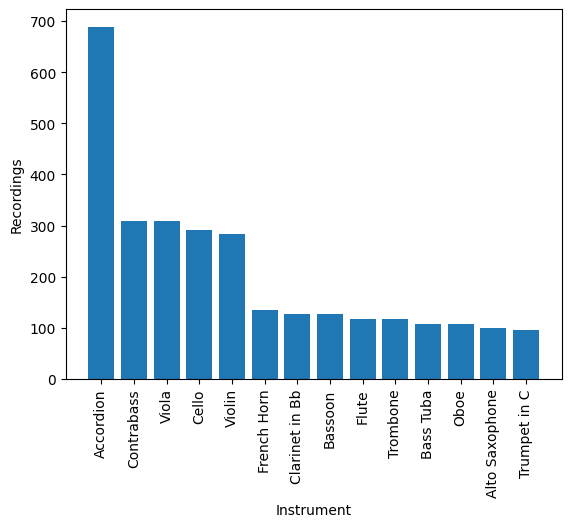

In [42]:
instrs = [rec.instrument_full for rec in tinysol.load_tracks().values()]
res = pd.Series(instrs).value_counts().reset_index(drop=False)

plt.bar(res["index"], res["count"])
plt.xticks(rotation=90)
plt.xlabel("Instrument")
plt.ylabel("Recordings")
plt.show()

Great, from looking at this plot, we can see that **the vast majority of recordings** are on the Accordion. We have over **two times as many Accordion recordings** as we do Contrabass, *the next most common class*. We might call a dataset like this **unbalanced**.

Next, we can look at the number of recordings by each **family** of instruments.

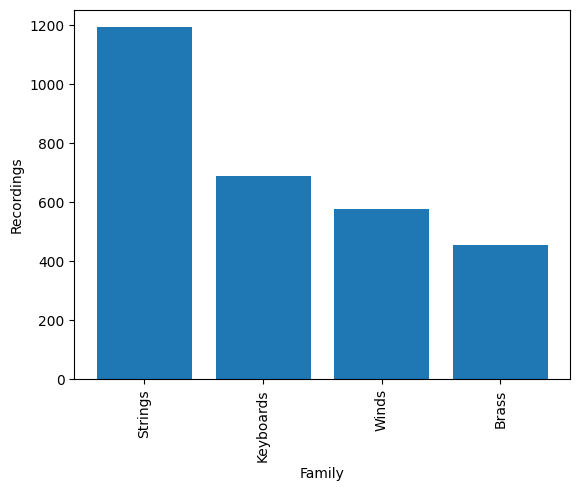

In [43]:
fams = [rec.family for rec in tinysol.load_tracks().values()]

# Note that this code is unchanged from the previous cell
res = pd.Series(fams).value_counts().reset_index(drop=False)
plt.bar(res["index"], res["count"])
plt.xticks(rotation=90)
plt.gca().set(xlabel="Family", ylabel="Recordings")
plt.show()

Great: we can see now that the vast majority of recordings are by instruments from the **string** family (e.g., **Violin**, **Viola**), whereas **brass** recordings (e.g., **Trumpet**, **Trombone**) are much less common in our dataset.

*What other exploratory analyses could we perform for this dataset?*

Think about:
- The duration of recordings
- The qualities of these recordings (e.g., the number of notes they contain)
- Anything else?

### 2.iii - Visualising the Waveform and Spectrogram 🎨

As we saw before, we have two ways of visualising audio information: the waveform, which shows the signals evolution in time, and the spectrogram, that shows the energy for different frequencies of the signal and how they change in time.

Let's look at at the waveform of our file:

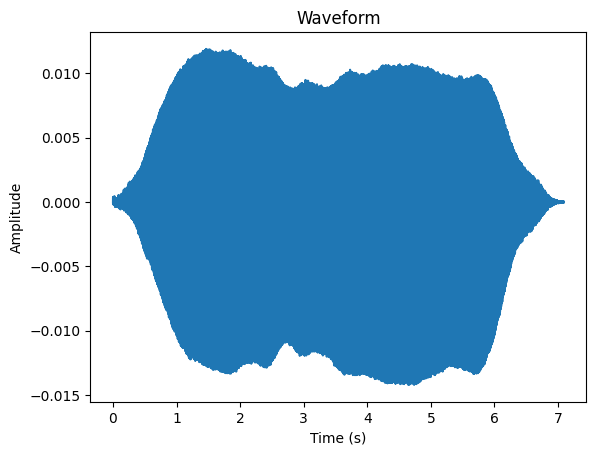

In [44]:
import numpy as np

x_seconds = np.arange(len(y)) / sr
plt.plot(x_seconds, y)
plt.gca().set(xlabel="Time (s)", ylabel="Amplitude")
plt.title("Waveform")
plt.show()

It is clear that the audio deals with only one note! For this particular track: How long does it take for it to reach the maximum amplitude? Does it reach it rapidly or does it increse gradually?

What about the spectrogram?

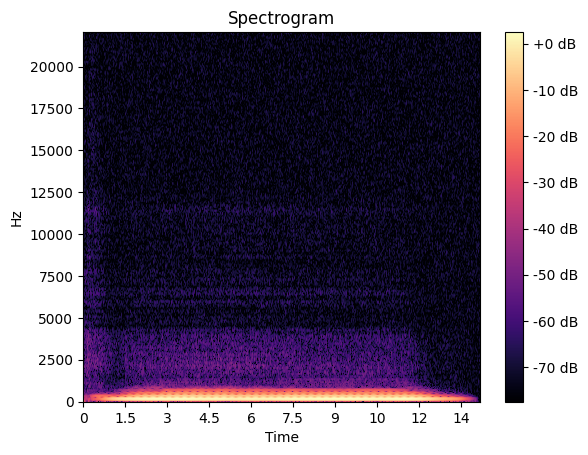

In [45]:
import librosa 

X_stft = np.abs(librosa.stft(y, win_length=512, hop_length=256))
spect = librosa.amplitude_to_db(X_stft)

librosa.display.specshow(spect, sr=sr, x_axis="time", y_axis="linear")
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.show()

What do you see? Is the energy concentrated in a certain frequency region or is it spread out? Does the distribution of energy across frequencies change over time or does it stay more or less the same?

### 2.iv - Feature Engineering 🔢

#### Feature Extraction

In the **Data Representations** notebook, we explored two types of **temporal features**:
1. **Root Mean Square**: measures the average loudness of a sound over time: a whisper has a low RMS, while a shout has a high RMS
2. **Zero-Crossing Rate**: the fraction of samples in a frame that cross 0, usually higher for noisy or percussive sounds

We also explored two **spectrotemporal features**:

3. **spectral centroid**: the average frequency of every **column** in the spectrogram
4. **spectral bandwidth**: the standard deviation of every **column** in the spectrogram


Now, we'll try to see how this **features** could help us understand the difference between instrument families, finding values for them for all the different **samples** of the dataset.

We're going to define a Python **function** that does the following:

1. Calculates the spectrogram corresponding to an audio file
2. Extracts the **four features** described above from every frame of the spectrogram
3. Gathers these features into a matrix with shape `(N_frames, N_features)`. In other words, every **row** is a frame, and every **column** is a feature.

In [46]:
def extract_features(waveform: np.ndarray, sr: float) -> np.ndarray:
    """
    Extracts features from an audio signal.

    Returns a 2D array, where each row is a frame and each column is a feature
    """
    # Compute the spectrogram
    X_stft = librosa.stft(waveform, win_length=512, hop_length=256)
    spect = np.abs(librosa.amplitude_to_db(np.abs(X_stft)))

    # Extract every feature
    spectral_centroids = librosa.feature.spectral_centroid(S=spect,)
    spectral_bandwidth = librosa.feature.spectral_bandwidth(S=spect,)
    rmse = librosa.feature.rms(S=spect,)
    zero_crossing_rate = librosa.feature.zero_crossing_rate(waveform, frame_length=512, hop_length=256)

    # Stack the features to the shape (N_frames, N_features)
    return np.vstack([
        spectral_centroids,
        spectral_bandwidth,
        rmse,
        zero_crossing_rate,
    ]).T


features = extract_features(y, sr)


Let's check the shape of the feature matrix:

In [47]:
print(features.shape)

(1222, 4)


Great! We can see the number of frames in order file as the first number in the tuple above. For every frame, we've extracted 4 **spectral features**.


#### Frames or Recordings? 🖼

While we could train our model on data extracted from every **frame**, there might be some problems with this:

- Given that each frame lasts a very short amount of time (around 0.01 second!), we might expect successive frames to contain **very similar information**;
- Some frames might not contain audio: for example, if the musician stopped playing **before the recording ended**. These frames could confuse a model.

Because of these reasons, we can instead **average** every feature for a single recording. Recall the equation for the mean of the values in a vector $x$:

$$
\text{mean}(x) = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

To calculate this, we can simply use `numpy`:

In [48]:
features_vector = np.mean(features, axis=0)
print(features_vector.shape)

(4,)


> **Good to know:** notice how we set the `axis=0` parameter above. This means that we **averaged over** the first axis in the matrix (i.e., frames). Compare the shape of `extracted` and `extracted_vector` to see what we mean.
>
> ***What would happen if we set `axis=1`? What shape would we get?***

We now have a **feature vector**: a one-dimensional vector with shape `(N_features,)`. Let's print this out:

In [49]:
print(features_vector.round(3))

[5.787571e+03 3.063084e+03 1.566000e+00 1.200000e-02]


#### Extract the features for our whole Database.

For each of the sample audios of the database we need to:

1. Load the audio file from TinySOL
2. Extract the six spectral features from every frame to create a matrix with shape `(N_frames, N_features)`
3. Average every feature over each frame to create a vector of shape `(N_features,)`

We can do that in a function, let's call it `get_averaged_features`

In [50]:
def get_averaged_features(track: tuple) -> np.ndarray:
    """
    Extract average features for a single recording.
    """
    # Extract the features for every frame: shape (N_frames, N_features)
    features = extract_features(track.audio[0], track.audio[1])
    # Average the features over all frames to create a vector: shape (N_features,)
    averaged_features = np.mean(features, axis=0)
    return averaged_features

But, how should we organise the storage of this information once we compute it?

We can stack this vector for every recording to create a matrix with shape `(N_recordings, N_features)`

Run the cell below to extract features from all the recordings in `tinysol`. Note that this may take a while, *so please be patient!*

In [51]:
# Load up all the recordings from tinysol
all_recordings = tinysol.load_tracks()
print(f"Number of recordings: {len(all_recordings)}")

Number of recordings: 2913


In [52]:
from joblib import Parallel, delayed

# Initialise an empty list to store all the feature vectors
all_features = []

# We would normally run the following code:

# for track in filtered_recordings.values():
#     all_features.append(get_averaged_features(track))

# The problem is that it is too slow! We're going to speed it up, but don't worry about the details,
# just know that this allows us to run several pieces of code at the same time (in parallel)

with Parallel(n_jobs=-1, verbose=5) as parallel:
    all_features = parallel(delayed(get_averaged_features)(track) for track in all_recordings.values())

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:   19.8s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:   22.3s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:   27.0s
[Parallel(n_jobs=-1)]: Done 272 tasks      | elapsed:   36.7s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   47.4s
[Parallel(n_jobs=-1)]: Done 632 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 866 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 1136 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 1442 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done 1784 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 2162 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done 2576 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done 2913 out of 2913 | elapsed:  4.2min finished


In [53]:
# Stack all of the vectors into a matrix with shape (N_recordings, N_features)
feature_matrix = np.array(all_features)

Great! We can confirm that our pipeline worked correctly by looking at the *shape of the feature matrix*:

In [54]:
print(feature_matrix.shape)

(2913, 4)


This shows we have 2913 recordings, the same number as in TinySOL. For each of these recordings, we have 4 features.

### 2.iv - Visualising Features 📃

Let's start taking a closer look at some of our features.

For now, we'll just visualise the spectral centroid and zero-crossing rate of each recording using **histograms**. These plots show the distribution of values by binning data into discrete groups.

We'll use the `seaborn` library to create these plots.

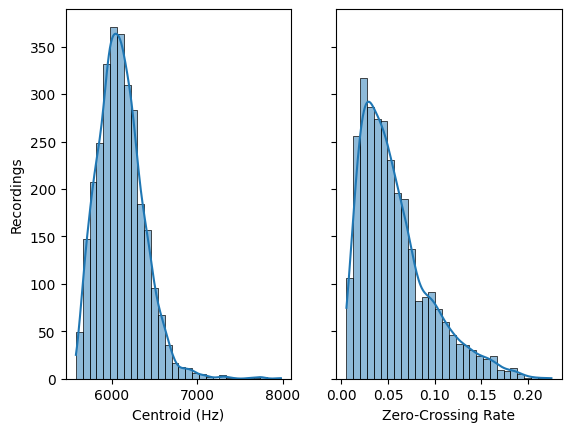

In [55]:
import seaborn as sns

fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True)

sns.histplot(feature_matrix[:, 0], kde='True', ax=ax[0], bins=30)
sns.histplot(feature_matrix[:, 3], kde='True', ax=ax[1], bins=30)

ax[0].set(xlabel="Centroid (Hz)", ylabel="Recordings")
ax[1].set(xlabel="Zero-Crossing Rate", ylabel="")

plt.show()

Now, this is for all the recordings group together. What would happen if we were to get one histogram per instrument family?

In [56]:
feature_names = ['Spectral Centroid', 'Spectral Bandwidth',
                 'RMS', 'Zero-Crossing Rate']
df_features = pd.DataFrame(feature_matrix, columns=feature_names)
# Get the family labels for coloring
families = [rec.family for rec in all_recordings.values()]
df_features['Family'] = families

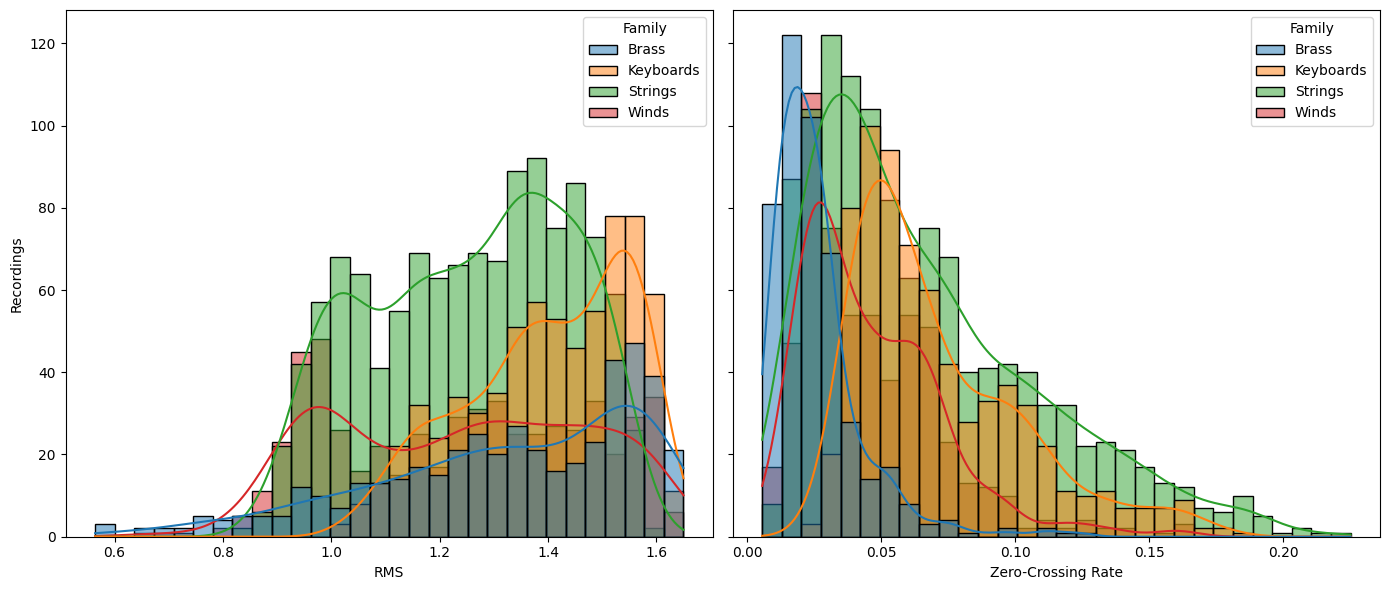

In [57]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(14, 6))

sns.histplot(data=df_features, x='RMS', hue='Family', kde='True', ax=ax[0], bins=30, multiple='layer', alpha=0.5)
sns.histplot(data=df_features, x='Zero-Crossing Rate', hue='Family', kde='True', ax=ax[1], bins=30, multiple='layer', alpha=0.5)

ax[0].set(xlabel="RMS", ylabel="Recordings")
ax[1].set(xlabel="Zero-Crossing Rate", ylabel="")

plt.tight_layout()
plt.show()

We can see different behaviour for different families! This gives us a glue that this features could be useful for analysing a recording and automatically indicate which family it belongs to. What about the other two features?

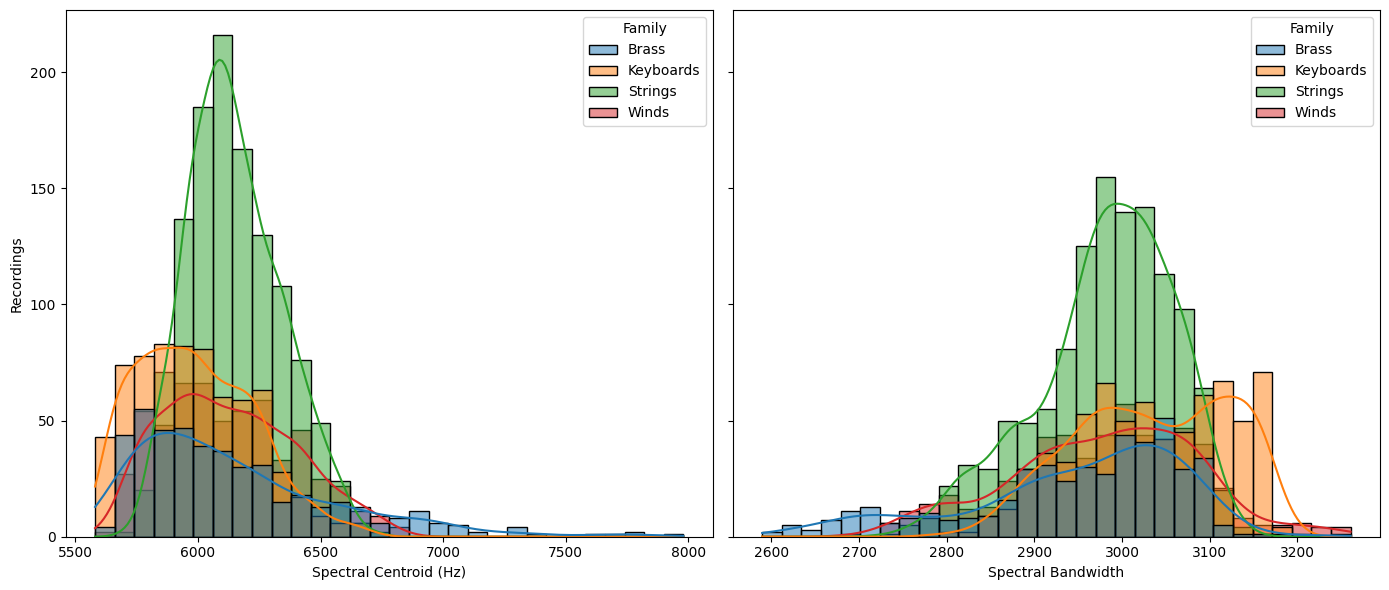

In [58]:
fig, ax = plt.subplots(nrows=1, ncols=2, sharex=False, sharey=True, figsize=(14, 6))

sns.histplot(data=df_features, x='Spectral Centroid', hue='Family', kde='True', ax=ax[0], bins=30, multiple='layer', alpha=0.5)
sns.histplot(data=df_features, x='Spectral Bandwidth', hue='Family', kde='True', ax=ax[1], bins=30, multiple='layer', alpha=0.5)

ax[0].set(xlabel="Spectral Centroid (Hz)", ylabel="Recordings")
ax[1].set(xlabel="Spectral Bandwidth", ylabel="")

plt.tight_layout()
plt.show()

Looking at all the graphs, can you see any feature better than the others at separating between families?

We will use all of this information for training a classifier in the next notebook. The features we have are:

In [59]:
df_features

,Spectral Centroid,Spectral Bandwidth,RMS,Zero-Crossing Rate,Family
0,5633.172265,3118.915778,1.649794,0.008589,Brass
1,5643.018662,3119.580742,1.627017,0.008592,Brass
2,5685.157258,3094.128050,1.610967,0.011369,Brass
3,5646.330359,3118.488256,1.627235,0.019568,Brass
4,5689.932701,3087.401249,1.633211,0.012646,Brass
...,...,...,...,...,...
2908,5992.137261,3092.541037,0.939491,0.126032,Winds
2909,6027.031350,3082.283561,1.122661,0.165413,Winds
2910,6037.915892,3090.484844,1.058522,0.160057,Winds
2911,5914.399967,3110.747552,0.997949,0.080559,Winds


## 3. Images : CIFAR-10

Now it's the time for images!

We will analyse the images from the [CIFAR-10 dataset](https://www.kaggle.com/competitions/cifar-10/data), consisting on 32x32 color images, belonging to one of these classes:
* airplane 
* automobile 
* bird 
* cat 
* deer 
* dog 
* frog 
* horse 
* ship 
* truck

### 3.i - Download dataset

First, let's download the dataset from `kaggle`:

In [60]:
# Download the CIFAR-10 dataset from Kaggle
!kaggle datasets download -d oxcdcd/cifar10

Dataset URL: https://www.kaggle.com/datasets/oxcdcd/cifar10
License(s): copyright-authors
cifar10.zip: Skipping, found more recently modified local copy (use --force to force download)


Let's extract it. We'll have a `labels.txt` file that indicates the name of the classes, and  `test` and `train` folders with images for the different classes. Don't worry about this distinction now, we will get to it in the next notebook!

In [61]:
with zipfile.ZipFile("cifar10.zip", 'r') as zip_ref:
    zip_ref.extractall("cifar10")

### 3.ii - Explore dataset

Let's look at some images we have for automobiles:

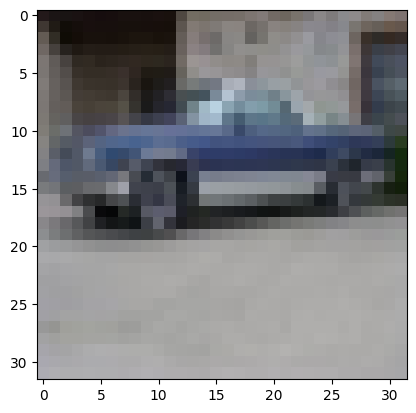

In [62]:
import skimage
import os

# change the label as you wish to explore the other classes!
label = 'automobile'
images_base_path = f'cifar10/cifar10/train/{label}/'
images_paths = os.listdir(images_base_path)

# change the index here to show a different image
index = 0
image_to_show = images_paths[index]
image = skimage.io.imread(os.path.join(images_base_path, image_to_show))
plt.imshow(image)

> Change the label and the index values in the code above to explore the dataset!

This dataset has been used heavily for classification tasks, that is, developing a system that given a new image that belongs to one of the defined classes, can confidently identify which class it belongs to.

For the sake of simplicity, we will now work with only two classes: `automobiles` and `airplanes`.

### 3.iii - Feature extraction

We can first analyse the colour histogram of the image we checked before.

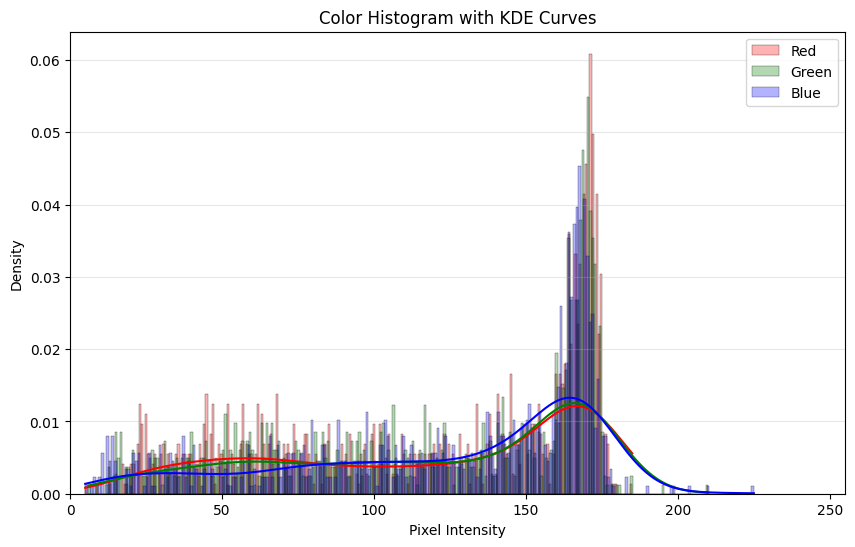

In [63]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# Extract each color channel
red = image[:, :, 0].flatten()
green = image[:, :, 1].flatten()
blue = image[:, :, 2].flatten()

# Plot histograms with KDE curves using seaborn
sns.histplot(red, bins=255, color='red', alpha=0.3, kde=True, label='Red', stat='density')
sns.histplot(green, bins=255, color='green', alpha=0.3, kde=True, label='Green', stat='density')
sns.histplot(blue, bins=255, color='blue', alpha=0.3, kde=True, label='Blue', stat='density')

plt.xlabel('Pixel Intensity')
plt.ylabel('Density')
plt.title('Color Histogram with KDE Curves')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xlim(0, 255)
plt.show()

Can we extend the code to average the histogram of the whole class?

In [64]:
def plot_histogram_for_class(label):
    images_base_path = f'cifar10/cifar10/train/{label}/'
    images_paths = os.listdir(images_base_path)

    plt.figure(figsize=(10, 6))

    # Initialize lists to accumulate all pixel values
    all_red = []
    all_green = []
    all_blue = []

    for image_name in images_paths[:5]:
        image = skimage.io.imread(os.path.join(images_base_path, image_name))
        # Extract each color channel
        all_red.extend(image[:, :, 0].flatten())
        all_green.extend(image[:, :, 1].flatten())
        all_blue.extend(image[:, :, 2].flatten())

    # Plot histograms with KDE curves using seaborn
    sns.histplot(all_red, bins=255, color='red', alpha=0.3, kde=True, label='Red', stat='density')
    sns.histplot(all_green, bins=255, color='green', alpha=0.3, kde=True, label='Green', stat='density')
    sns.histplot(all_blue, bins=255, color='blue', alpha=0.3, kde=True, label='Blue', stat='density')

    plt.xlabel('Pixel Intensity')
    plt.ylabel('Density')
    plt.title(f'Color Histogram with KDE Curves - {label.title()}')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(0, 255)
    plt.show()

For the case of automobiles this would be:

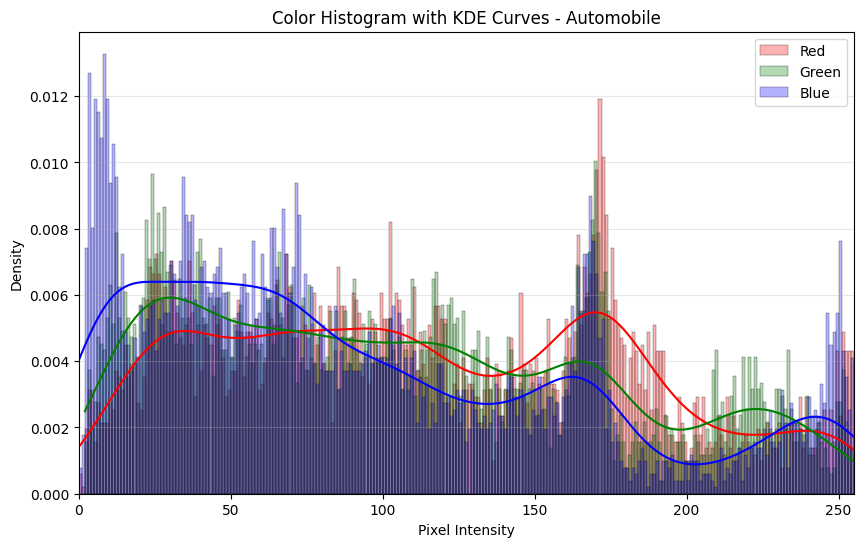

In [65]:
plot_histogram_for_class('automobile')

While for the airplane we would have:

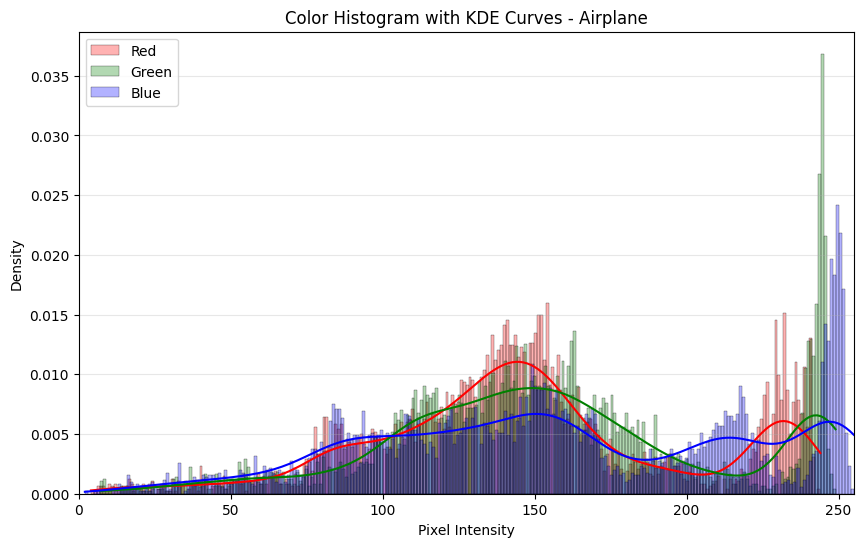

In [66]:
plot_histogram_for_class('airplane')

We can see that the colour histograms for the two classes are completely diferent on average!

For our further processing, we need statistical information for each image, so our model can learn from examples.

To summarise the information in numbers, we can calculate the mean and standard deviation of each channel of each image:

In [67]:
def extract_color_stats(image):
    """
    Extract mean and standard deviation for each color channel (RGB).
    
    Returns a vector with 6 features: [mean_R, mean_G, mean_B, std_R, std_G, std_B]
    """
    red = image[:, :, 0].flatten()
    green = image[:, :, 1].flatten()
    blue = image[:, :, 2].flatten()
    
    stats = [
        np.mean(red), np.mean(green), np.mean(blue),
        np.std(red), np.std(green), np.std(blue)
    ]
    
    return np.array(stats)

# Test on the current image
color_stats = extract_color_stats(image)
print("Color statistics (mean_R, mean_G, mean_B, std_R, std_G, std_B):")
print(color_stats.round(2))

Color statistics (mean_R, mean_G, mean_B, std_R, std_G, std_B):
[118.18 119.5  122.87  51.52  50.72  49.87]


We could then calculate those values for all the images in our dataset, and be ready for training in the next notebook.

In [96]:
images_stats = np.zeros((0, 6))  # Initialize an empty array to store stats for all images
labels = []

for label in ['automobile', 'airplane']:
    images_base_path = f'cifar10/cifar10/train/{label}/'
    images_paths = os.listdir(images_base_path)
    for image in images_paths:
        img = skimage.io.imread(os.path.join(images_base_path, image))
        stats = extract_color_stats(img)
        images_stats = np.vstack([images_stats, stats])  # Append the stats to the array
        labels.append(label)

What does our table of features look like?

In [69]:
df_images = pd.DataFrame(images_stats, columns=['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B'])
df_images['label'] = labels
df_images.head()

,mean_R,mean_G,mean_B,std_R,std_G,std_B,label
0,118.180664,119.496094,122.874023,51.516244,50.720030,49.866646,automobile
1,153.441406,141.306641,125.672852,61.136538,64.113088,65.829187,automobile
2,86.692383,41.961914,20.034180,69.927963,33.743627,19.912891,automobile
3,107.335938,97.231445,70.627930,69.433453,64.765579,38.634369,automobile
4,109.796875,129.926758,125.689453,61.164032,71.888990,88.644751,automobile


We can work with that, but he haven't used the edges information yet.

Let's define a function to get the edges of grayscale image:

In [70]:
def get_edges(image):
    edges_threshold = 0.1  # You can adjust this threshold value

    # Get the dimensions of the image
    height = image.shape[0]
    width = image.shape[1]

    # Create an empty array to store the edges
    vertical_diff = np.zeros((height, width))
    horizontal_diff = np.zeros((height, width))
    edges = np.zeros((height, width))

    # Loop through each pixel (except the edges of the image)
    for row in range(1, height - 1):
        for col in range(1, width - 1):
            # Get the neighboring pixel values
            top_pixel = image[row, col]
            bottom_pixel = image[row + 1, col]

            left_pixel = image[row, col]
            right_pixel = image[row, col + 1]

            # Calculate the differences
            vertical_diff = abs(bottom_pixel - top_pixel)
            horizontal_diff = abs(right_pixel - left_pixel)

            if vertical_diff > edges_threshold or horizontal_diff > edges_threshold:
                edges[row, col] = 1.0  # Mark as edge

    return edges

Let's create another function to extract statistics from the edges. One interesting metric is the edges density, defined as

$$ edge density = \# pixels that are an edge / \# pixels $$

This could be calculated for the whole image, or, in order to also have spatial information, it could be calculated for different parts of the image if we divide it in a grid. Let's divide the image in a 4x4 grid and calculate separate densities for each quadrant!

In [ ]:
def extract_edges_stats(image):
    """
    Extract edge features using Canny edge detection.
    
    Returns statistics about the edges: [num_edges, edge_density, edge_mean, edge_std]
    """
    # Convert to grayscale if RGB
    if len(image.shape) == 3:
        gray = skimage.color.rgb2gray(image)
    else:
        gray = image
    
    # Apply Canny edge detection
    edges = get_edges(gray)
    
    # Divide image into 4x4 grid and calculate edge density for each region
    h, w = edges.shape
    grid_h, grid_w = h // 4, w // 4
    edge_densities = []
    for i in range(4):
        for j in range(4):
            region = edges[i*grid_h:(i+1)*grid_h, j*grid_w:(j+1)*grid_w]
            region_density = np.sum(region) / region.size
            edge_densities.extend([region_density])
    
    return np.array(edge_densities)

Let's calculate all the stats for each image.

In [100]:
edges_stats = np.zeros((0, 16))  # Initialize an empty array to store stats for all images
labels = []

for label in ['automobile', 'airplane']:
    images_base_path = f'cifar10/cifar10/train/{label}/'
    images_paths = os.listdir(images_base_path)
    for image in images_paths:
        img = skimage.io.imread(os.path.join(images_base_path, image))
        stats = extract_edges_stats(img)
        edges_stats = np.vstack([edges_stats, stats])  # Append the stats to the array
        labels.append(label)

In [102]:
df_edges = pd.DataFrame(edges_stats, columns=[f'edge_density_{i}' for i in range(16)])
df_edges['label'] = labels
df_edges.head()

,edge_density_0,edge_density_1,edge_density_2,edge_density_3,edge_density_4,edge_density_5,edge_density_6,edge_density_7,edge_density_8,edge_density_9,edge_density_10,edge_density_11,edge_density_12,edge_density_13,edge_density_14,edge_density_15,label
0,0.09375,0.359375,0.156250,0.234375,0.281250,0.578125,0.562500,0.390625,0.359375,0.375000,0.343750,0.218750,0.000000,0.000000,0.000000,0.000000,automobile
1,0.59375,0.609375,0.671875,0.171875,0.421875,0.296875,0.421875,0.375000,0.265625,0.609375,0.500000,0.031250,0.062500,0.125000,0.421875,0.375000,automobile
2,0.00000,0.000000,0.031250,0.046875,0.078125,0.000000,0.281250,0.171875,0.234375,0.359375,0.640625,0.109375,0.000000,0.031250,0.062500,0.015625,automobile
3,0.21875,0.609375,0.406250,0.562500,0.484375,0.578125,0.421875,0.437500,0.515625,0.468750,0.500000,0.031250,0.375000,0.687500,0.171875,0.015625,automobile
4,0.00000,0.000000,0.015625,0.171875,0.437500,0.578125,0.531250,0.593750,0.453125,0.281250,0.265625,0.359375,0.078125,0.234375,0.109375,0.093750,automobile


Finally, we have this features:

In [103]:
images_features = pd.concat([df_images.drop(columns='label'), df_edges.drop(columns='label')], axis=1)
images_features['label'] = labels
images_features.head()

,mean_R,mean_G,mean_B,std_R,std_G,std_B,edge_density_0,edge_density_1,edge_density_2,edge_density_3,...,edge_density_7,edge_density_8,edge_density_9,edge_density_10,edge_density_11,edge_density_12,edge_density_13,edge_density_14,edge_density_15,label
0,118.180664,119.496094,122.874023,51.516244,50.720030,49.866646,0.09375,0.359375,0.156250,0.234375,...,0.390625,0.359375,0.375000,0.343750,0.218750,0.000000,0.000000,0.000000,0.000000,automobile
1,153.441406,141.306641,125.672852,61.136538,64.113088,65.829187,0.59375,0.609375,0.671875,0.171875,...,0.375000,0.265625,0.609375,0.500000,0.031250,0.062500,0.125000,0.421875,0.375000,automobile
2,86.692383,41.961914,20.034180,69.927963,33.743627,19.912891,0.00000,0.000000,0.031250,0.046875,...,0.171875,0.234375,0.359375,0.640625,0.109375,0.000000,0.031250,0.062500,0.015625,automobile
3,107.335938,97.231445,70.627930,69.433453,64.765579,38.634369,0.21875,0.609375,0.406250,0.562500,...,0.437500,0.515625,0.468750,0.500000,0.031250,0.375000,0.687500,0.171875,0.015625,automobile
4,109.796875,129.926758,125.689453,61.164032,71.888990,88.644751,0.00000,0.000000,0.015625,0.171875,...,0.593750,0.453125,0.281250,0.265625,0.359375,0.078125,0.234375,0.109375,0.093750,automobile


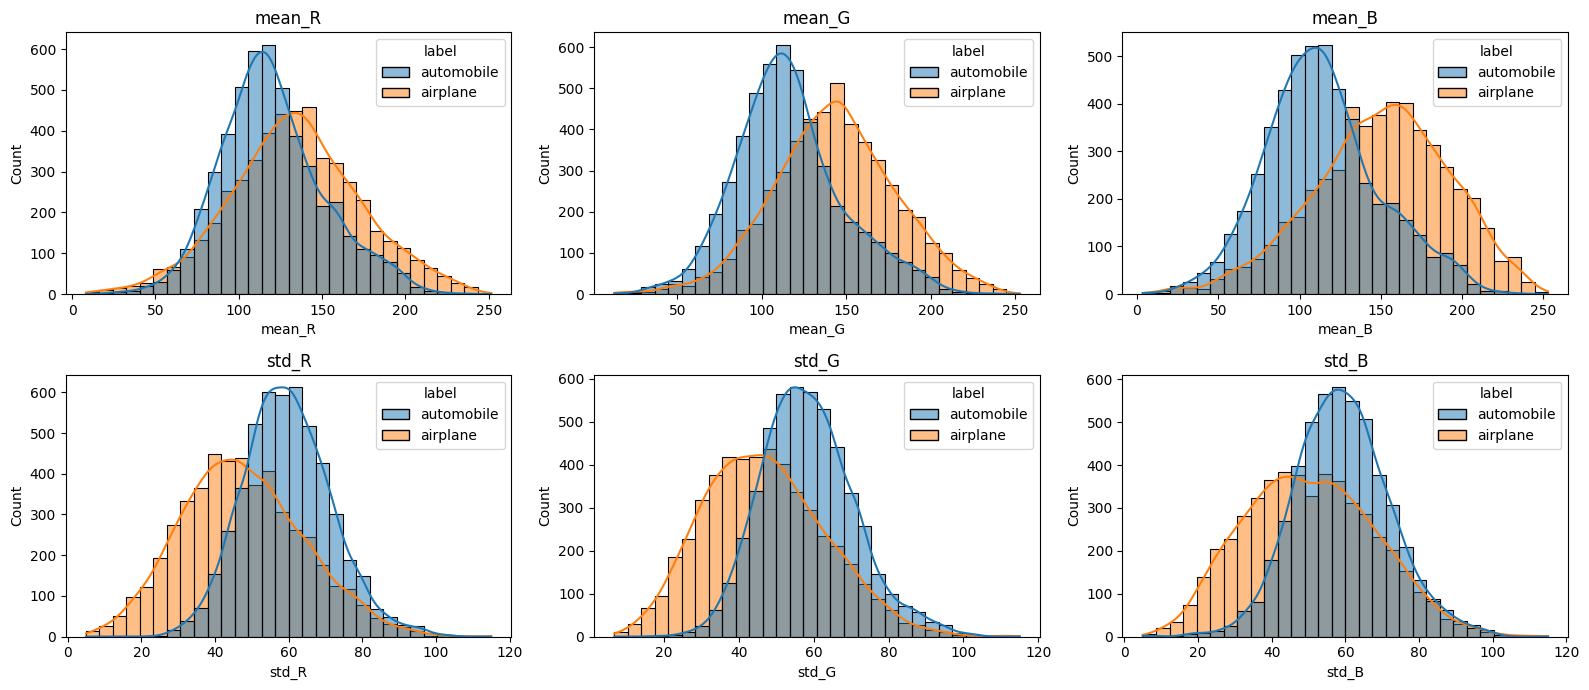

In [108]:
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()

feat_cols = ['mean_R', 'mean_G', 'mean_B', 'std_R', 'std_G', 'std_B']

for i, col in enumerate(feat_cols):
    sns.histplot(data=images_features, x=col, hue='label', kde=True, bins=30, ax=axes[i], alpha=0.5)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

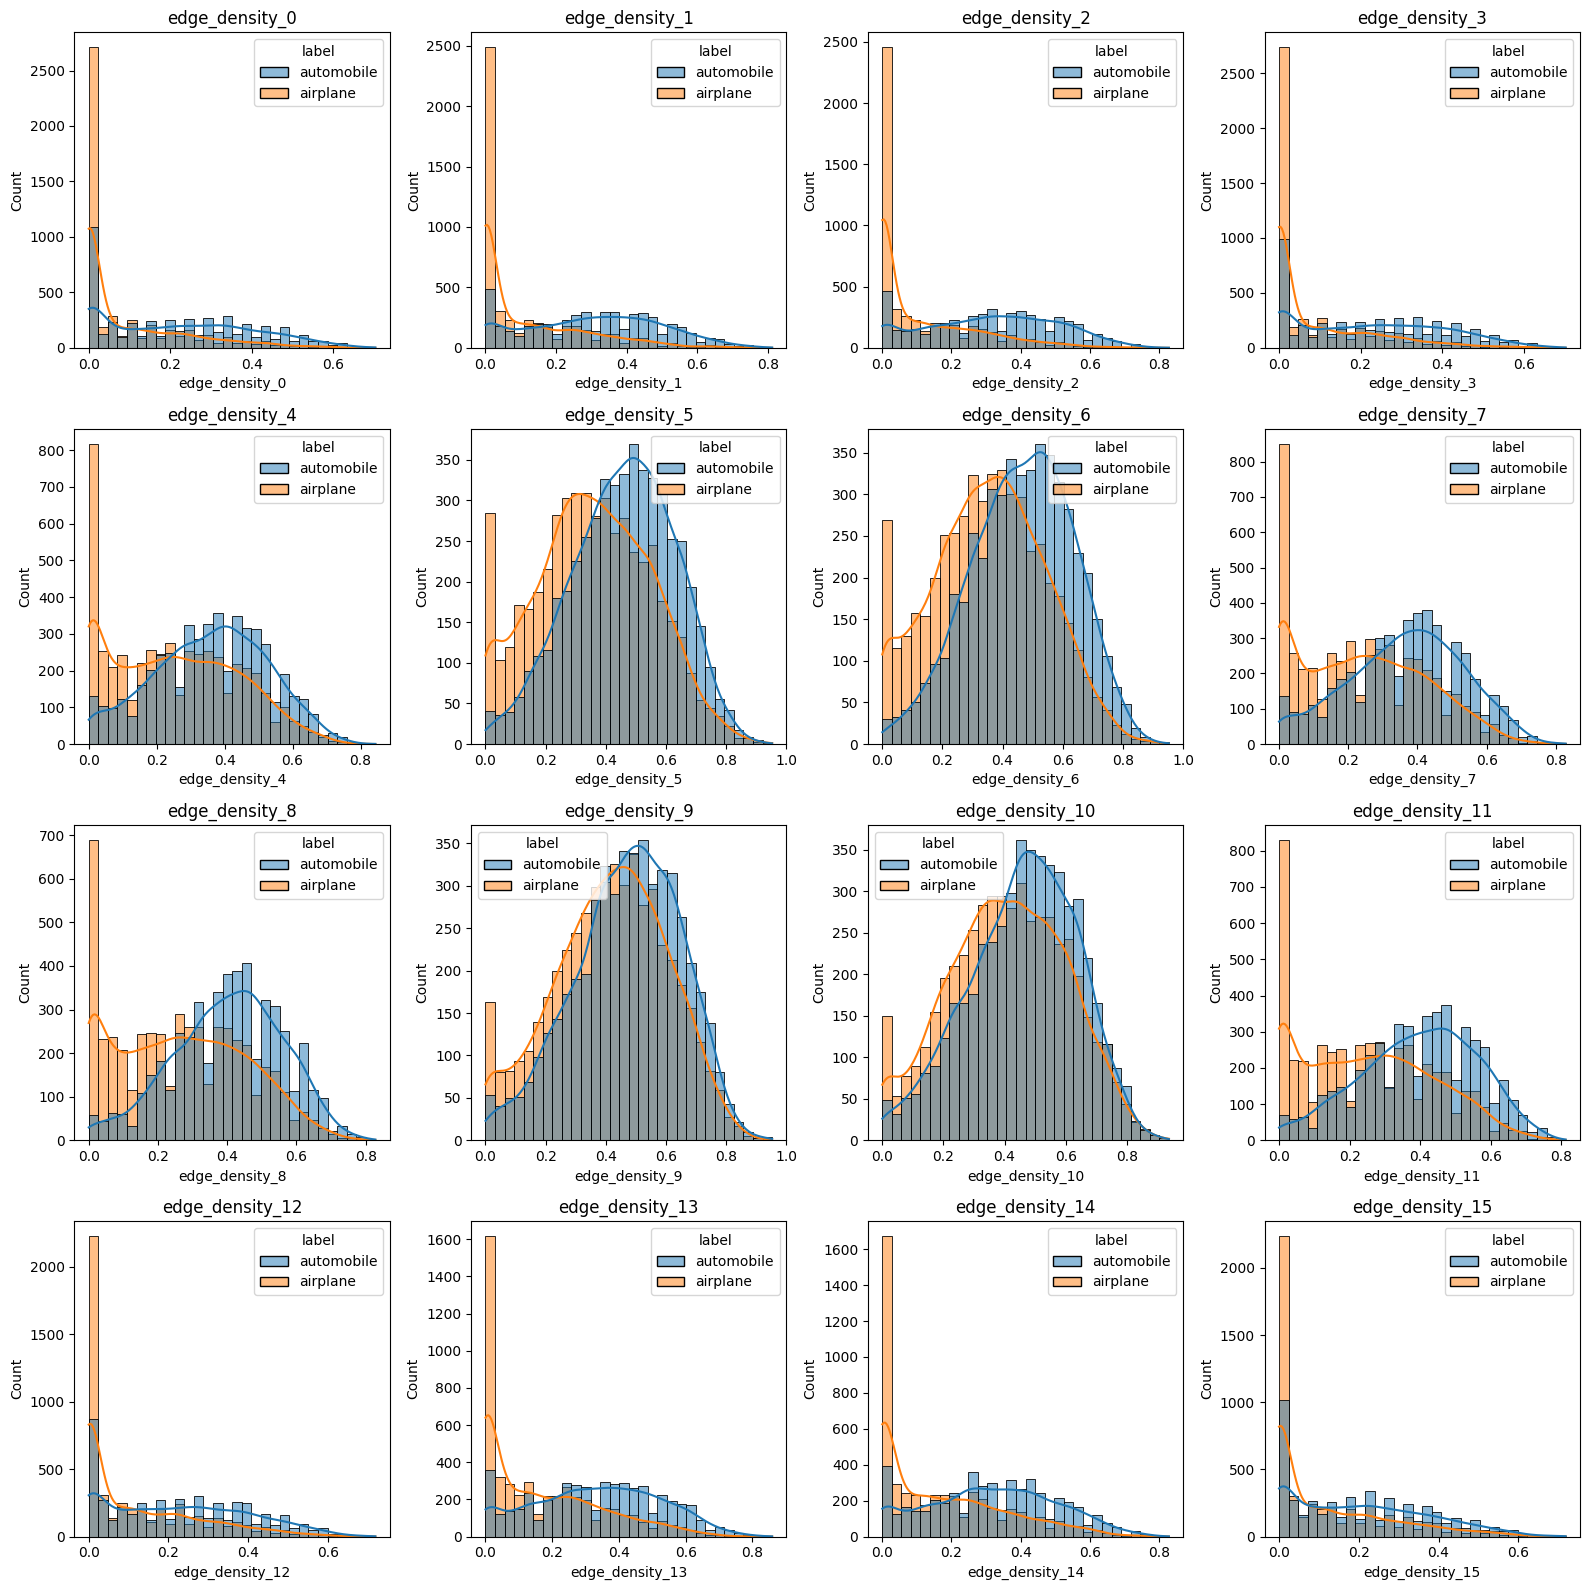

In [110]:
fig, axes = plt.subplots(4, 4, figsize=(16, 16))
axes = axes.flatten()

feat_cols = [f'edge_density_{i}' for i in range(16)]

for i, col in enumerate(feat_cols):
    sns.histplot(data=images_features, x=col, hue='label', kde=True, bins=30, ax=axes[i], alpha=0.5)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

# Conclusion: Datasets
